Handiling Missing Data




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_excel('large_ml_cleaning_practice.xlsx')
df.head()

,Player_ID,Player_Name,Team,Matches_Played,Runs_Scored,Batting_Avg,Strike_Rate,Wickets,Economy_Rate,Role,Salary_Lakhs,Fitness_Status
0,1001,Jos Sharma,West Indies,71,566,26.34,96.84,99.0,11.35,batsman,72.0,Injured
1,1002,Nicholas Rabada,ENGLAND,45,NaN,NaN,144.26,18.0,10.00,BOWLER,1172.0,Rehab
2,1003,Quinton Warner,INDIA,132,935,25.88,NaN,93.0,9.26,BOWLER,1238.0,Injured
3,1004,Glenn Dhoni,Sri Lanka,36,1934,28.10,130.04,112.0,7.17,BOWLER,NaN,NaN
4,1005,Dasun Yadav,West Indies,70,2708,54.52,134.24,145.0,10.77,Bowler,144.0,Fit


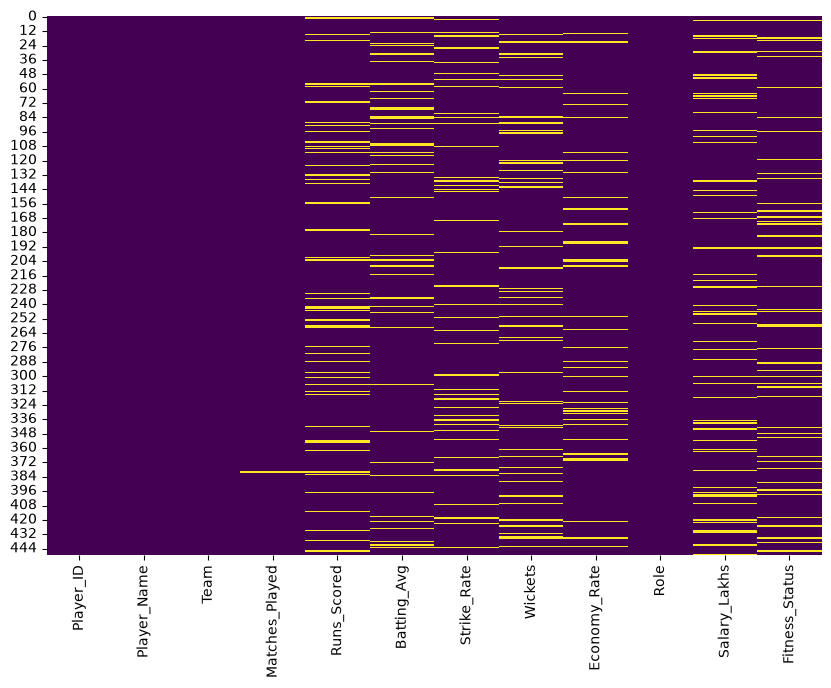

In [3]:
df.shape
df.isnull().sum()
plt.figure(figsize=(10,7))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

In [4]:
null_percentage = df.isnull().sum().sum()/(df.shape[0] * df.shape[1]) * 100
not_null_percentage = 100 - null_percentage
null_count = df.isnull().sum().sum()
not_null_count = df.notnull().sum().sum()
print('Percentage of null values in the dataset is: ', null_count, null_percentage)
print('Percentage of not null values in the dataset is: ', not_null_count, not_null_percentage)
df.isnull().sum()


Percentage of null values in the dataset is:  326 6.037037037037037
Percentage of not null values in the dataset is:  5074 93.96296296296296


Player_ID          0
Player_Name        0
Team               0
Matches_Played     1
Runs_Scored       50
Batting_Avg       44
Strike_Rate       45
Wickets           49
Economy_Rate      37
Role               0
Salary_Lakhs      53
Fitness_Status    47
dtype: int64

In [ ]:
numeric_columns = df.select_dtypes(include="float64").columns

Index(['Batting_Avg', 'Strike_Rate', 'Wickets', 'Economy_Rate',
       'Salary_Lakhs'],
      dtype='str')

In [ ]:
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
df = pd.read_excel('large_ml_cleaning_practice.xlsx')


# numeric_columns = ['Player_ID', 'Batting_Avg', 'Strike_Rate', 'Wickets', 'Economy_Rate', 'Salary_Lakhs']
si = SimpleImputer(strategy='mean')
ar= si.fit_transform(df[numeric_columns])
new_df = pd.DataFrame(ar, columns=numeric_columns)

new_df 



,Player_ID,Batting_Avg,Strike_Rate,Wickets,Economy_Rate,Salary_Lakhs
0,1001.0,26.340000,96.840000,99.0,11.35,72.000000
1,1002.0,32.457488,144.260000,18.0,10.00,1172.000000
2,1003.0,25.880000,129.693136,93.0,9.26,1238.000000
3,1004.0,28.100000,130.040000,112.0,7.17,1225.322418
4,1005.0,54.520000,134.240000,145.0,10.77,144.000000
...,...,...,...,...,...,...
445,1446.0,34.820000,94.900000,0.0,11.71,2021.000000
446,1447.0,32.280000,149.540000,107.0,8.71,2153.000000
447,1448.0,27.220000,154.590000,18.0,6.69,2249.000000
448,1449.0,5.730000,178.200000,75.0,8.50,495.000000
